# Data Science Course Cirriculum Development
 Data Preprocessing

In [4]:
import pandas as pd
import numpy as np
import re

# Load the dataset
file_path = 'Supplemental_Python_Remote.csv'
job_descriptions_df = pd.read_csv(file_path)

# Function to clean text
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\b\w{1,2}\b', '', text)  # Remove short words
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

# Clean the Combined column
job_descriptions_df['Cleaned_Combined'] = job_descriptions_df['Combined'].fillna('').apply(clean_text)

# Display the first few cleaned texts
print("\nFirst few cleaned job descriptions:")
print(job_descriptions_df['Cleaned_Combined'].head())



First few cleaned job descriptions:
0    python developer put patents into business con...
1    software engineer python pyspark this direct h...
2    entry level technician position overview seek ...
3    epidemiologist python sas descriptionoverview ...
4    data analyst opt ead only h1b job summary are ...
Name: Cleaned_Combined, dtype: object


 Feature 1 : %Part-time 

Feature 2 : %Remote

In [5]:
# Encode job type (Part-time) and remote work
job_descriptions_df['Part_Time'] = job_descriptions_df['Title'].apply(lambda x: 1 if 'part-time' in x.lower() else 0)
job_descriptions_df['Remote'] = job_descriptions_df['Location'].apply(lambda x: 1 if 'remote' in x.lower() else 0)

part_time_percent = job_descriptions_df['Part_Time'].mean() * 100
remote_percent = job_descriptions_df['Remote'].mean() * 100

print(f"Part-time %: {part_time_percent}")
print(f"Remote %: {remote_percent}")


Part-time %: 0.07423904974016332
Remote %: 99.95050730017321


 Feature 3 : Average Years of Experience

In [6]:
def extract_experience(description):
    experience = re.findall(r'(\d+) year', description)
    experience = [int(x) for x in experience]
    return np.mean(experience) if experience else 0

job_descriptions_df['Experience_Years'] = job_descriptions_df['Descriptions'].apply(lambda x: extract_experience(x) if pd.notna(x) else 0)

average_experience = job_descriptions_df['Experience_Years'].mean()

print(f"Average years of experience: {average_experience}")


Average years of experience: 1.3976468113810354


 Feature 4 : Education Level

In [7]:
import json 

# Mapping of education levels to a numerical scale for averaging
education_levels = {
    'high school': 1,
    'associate': 2,
    'bachelor': 3,
    'master': 4,
    'phd': 5,
    'doctorate': 5  # Equating PhD and doctorate for simplicity
}

# Function to extract the education level from a job description
def extract_education_level(description):
    if pd.isnull(description):
        return None
    
    description = description.lower()
    for level, rank in education_levels.items():
        if level in description:
            return rank
    return None

# Apply the extract_education_level function to the job descriptions
job_descriptions_df['Education Level'] = job_descriptions_df['Cleaned_Combined'].apply(extract_education_level)

# Calculate the average education level
average_education_level = job_descriptions_df['Education Level'].mean()

# Print the average education level
print(f"Average Education Level: {average_education_level}")

# Save the collected education levels to a JSON file
education_info = job_descriptions_df[['Cleaned_Combined', 'Education Level']].to_dict(orient='records')

with open('education_levels.json', 'w') as json_file:
    json.dump(education_info, json_file, indent=4)

Average Education Level: 2.8467087466185754


Feature 5 : Position Level

In [8]:
import pandas as pd

# Mapping of job levels to a numerical scale for averaging
job_levels = {
    'intern': 1,
    'entry': 2,
    'junior': 3,
    'associate': 4,
    'mid': 5,
    'senior': 6,
    'lead': 7,
    'manager': 8,
    'director': 9,
    'chief': 10
}

# Function to extract the job level from a job title
def extract_job_level(title):
    if pd.isnull(title):
        return None
    
    title = title.lower()
    for job_level, level_score in job_levels.items():
        if job_level in title:
            return level_score
    return None

# Apply the extract_job_level function to the job titles
job_descriptions_df['Job Level'] = job_descriptions_df['Title'].apply(extract_job_level)

# Calculate the average job level
average_job_level = job_descriptions_df['Job Level'].mean()

# Print the average job level
print(f"Average Job Level: {average_job_level}")

# Save the collected job levels to a JSON file
job_level_info = job_descriptions_df[['Title', 'Job Level']].to_dict(orient='records')

with open('job_levels.json', 'w') as json_file:
    json.dump(job_level_info, json_file, indent=4)


Average Job Level: 6.143659711075442


 Feature 5 : GPT level of difficulty

In [42]:
import openai
from openai import OpenAI
import json
# OpenAI API key
openai.api_key = 'REDACTED'

client = OpenAI()

def rate_job_difficulty(posting):
    response = client.chat.completions.create(
        model="gpt-4-0125-preview",
        messages=[
            {"role": "system", "content": "You are a helpful assistant specialized in analyzing job postings and rating the difficulty of the job."},
            {"role": "user", "content": f"""Rate the difficulty of the following job posting on a scale of 1 to 10:
            {posting}
            Format the output as a JSON object with a single key 'difficulty' and an integer value.

            Example: {{
                "difficulty": 7
            }}
            """}
        ], 
        max_tokens=4096,
        temperature=0,
        top_p=1
    )

    response_content = response.choices[0].message.content
    # Print the raw response content for debugging
    print(response_content)

    # Attempt to parse the response content as JSON
    try:
        # Extract the JSON part from the response content
        json_start = response_content.find('{')
        json_end = response_content.rfind('}') + 1
        json_content = response_content[json_start:json_end]
        result = json.loads(json_content)
    except json.JSONDecodeError:
        # Handle JSON decoding error
        print("Error: Failed to parse JSON response.")
        return {"difficulty": 0}

    return result

In [45]:
all_difficulties = []
for posting in job_descriptions_df['Cleaned_Combined']:
    difficulty = rate_job_difficulty(posting)
    all_difficulties.append(difficulty)

# Save the collected difficulties to a JSON file
with open('job_difficulties.json', 'w') as json_file:
    json.dump(all_difficulties, json_file, indent=4)

```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 6
}
```
```json
{
    "difficulty": 3
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 6
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 9
}
```
```json
{
    "difficulty": 7
}
```
```json
{
    "difficulty": 2
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 3
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 6
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 7
}
```
```json
{
    "difficulty": 9
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 6
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 6
}
```
```json
{
    "difficulty": 6
}
```
```json
{
    "difficulty": 8
}
```
```json
{
    "difficulty": 

In [31]:
import pandas as pd
import json

# Load the difficulties from the JSON file
with open('job_difficulties.json', 'r') as json_file:
    difficulties = json.load(json_file)

# Assuming difficulties is a list of dictionaries, each with a "difficulty" key
# Extract the difficulty values
difficulty_values = [d['difficulty'] for d in difficulties]

# Ensure that the number of difficulties matches the number of job postings
if len(difficulty_values) != len(job_descriptions_df):
    raise ValueError("The number of difficulties does not match the number of job postings.")

# Add the difficulty column to the DataFrame
job_descriptions_df['Difficulty'] = difficulty_values
# Convert 'Difficulty' to numeric, forcing errors to NaN (useful if there are non-numeric values)
job_descriptions_df['Difficulty'] = pd.to_numeric(job_descriptions_df['Difficulty'], errors='coerce')

# Fill NaN values with a default value or handle them as needed
job_descriptions_df['Difficulty'] = job_descriptions_df['Difficulty'].fillna(-1).astype(int)

Feature 6 : How far into description is skill mentioned
(the skill list needs to be parsed for correct extraction)

In [10]:
import numpy as np
import pandas as pd

# Define the skill mention position function
def skill_mention_position(description, skill):
    words = description.split()
    skill_lower = skill.lower()
    for i, word in enumerate(words):
        if skill_lower in word.lower():
            return i / len(words)
    return np.nan


# Load skills list from Excel
skills_df = pd.read_excel('Hyphen_Removed_Skills_Data.xlsx')
skills_list = skills_df.iloc[:, 2].dropna().tolist()
skills_list = pd.unique(skills_list)

# Compute average position of skill mentions for each job description
avg_skill_positions = []

for index, row in job_descriptions_df.iterrows():
    description = row['Cleaned_Combined']
    skill_positions = []
    for skill in skills_list:
        position = skill_mention_position(description, skill)
        if not pd.isna(position):
            skill_positions.append(position)
    if skill_positions:
        avg_position = np.mean(skill_positions)
    else:
        avg_position = np.nan
    avg_skill_positions.append(avg_position)

# Create a DataFrame with only the average skill position column
avg_skill_positions_df = pd.DataFrame({
    'Avg_Skill_Position': avg_skill_positions
})

# Save the DataFrame with only the average skill position column to a CSV file
avg_skill_positions_df.to_csv('avg_skill_positions.csv', index=False)

# Calculate overall average position considering only mentioned skills
overall_avg_position = np.nanmean(avg_skill_positions)

print(f"Overall average position of skill mention: {overall_avg_position}")


/var/folders/b7/5s7w4rhj08n_d300vg9kq81m0000gn/T/ipykernel_35924/4002759894.py:17: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  skills_list = pd.unique(skills_list)


Overall average position of skill mention: 0.2842573789945938


In [11]:
# Load the CSV file with average skill positions
avg_skill_positions_df = pd.read_csv('avg_skill_positions.csv')

# Ensure the number of rows matches
if len(job_descriptions_df) != len(avg_skill_positions_df):
    raise ValueError("The number of rows in the CSV file does not match the number of rows in the job descriptions DataFrame.")

# Add the Avg_Skill_Position column to the job descriptions DataFrame
job_descriptions_df['Avg_Skill_Position'] = avg_skill_positions_df['Avg_Skill_Position']

In [12]:
job_descriptions_df.columns

Index(['Title', 'Company', 'Location', 'Rating', 'Date', 'Salary',
       'Description', 'Links', 'Descriptions', 'Combined', 'Cleaned_Combined',
       'Part_Time', 'Remote', 'Experience_Years', 'Education Level',
       'Job Level', 'Difficulty', 'Avg_Skill_Position'],
      dtype='object')

Feature 8 : Number of unique companies 

Feature 9 : Number of unique job titles (skill versatility)

In [28]:
unique_companies = job_descriptions_df['Company'].nunique()
unique_job_titles = job_descriptions_df['Title'].nunique()

print(f"Number of unique companies: {unique_companies}")
print(f"Number of unique job titles: {unique_job_titles}")


Number of unique companies: 1338
Number of unique job titles: 1401


Feature 10 : Average salary

Feature 11 : Highest Salary

In [13]:
import re

# Function to clean and parse salary data
def parse_annual_salary(salary):
    if pd.isnull(salary):
        return None

    # Define a full-time work year as 40 hours/week * 50 weeks/year
    full_time_hours_per_year = 40 * 50

    # Remove currency symbols and commas, and handle upper/lower case uniformly
    salary = salary.replace('$', '').replace(',', '').lower().strip()
    # Find numeric values
    numbers = re.findall(r'\d+', salary)

    # If the salary contains "up to" and "an hour"
    if 'up to' in salary and 'an hour' in salary and numbers:
        hourly_rate = float(numbers[0])
        return hourly_rate * full_time_hours_per_year

    # If the salary is just an hourly rate without "up to"
    elif 'an hour' in salary and numbers:
        hourly_rate = float(numbers[0])
        return hourly_rate * full_time_hours_per_year

    # If the salary contains a range
    elif '-' in salary and numbers:
        # If it's an hourly range, calculate the average
        if 'an hour' in salary:
            salary_range = [float(value) for value in numbers[:2]]  # Assume first two are the range values
            return (sum(salary_range) / len(salary_range)) * full_time_hours_per_year
        else:
            # For annual range, calculate the average and convert to hourly
            salary_range = [float(value) for value in numbers[:2]]  # Assume first two are the range values
            annual_average = sum(salary_range) / len(salary_range)
            return annual_average

    # If the salary is a single number, it could be a yearly salary
    elif numbers:
        # Convert the first found number to float and assume it is yearly salary
        yearly_salary = float(numbers[0])

        return yearly_salary

    return None  # In case of any other format that isn't covered


In [14]:
job_descriptions_df['Annual Salary'] = job_descriptions_df['Salary'].apply(parse_annual_salary)


In [40]:
job_descriptions_df['Annual Salary'].isna().sum()

3247

 Feature 12 : Number of times 'Certificate' is mentioned in descriptions where this skill is mentioned

In [3]:
# Load skills list from Excel
skills_df = pd.read_excel('Hyphen_Removed_Skills_Data.xlsx')
skills_list = skills_df.iloc[:, 2].dropna().tolist()
# print(skills_list[:10])

In [53]:
job_descriptions_df['Certificate_Mentioned'] = job_descriptions_df['Cleaned_Combined'].apply(lambda x: x.lower().count('certificate') if pd.notna(x) else 0)

certificate_mentions = job_descriptions_df['Certificate_Mentioned'].sum()

print(f"Number of times 'Certificate' is mentioned: {certificate_mentions}")

Number of times 'Certificate' is mentioned: 33


In [4]:
# Create the Certificate_Mentioned column
job_descriptions_df['Certificate_Mentioned'] = 0

# Update the Certificate_Mentioned column based on skill presence
for index, row in job_descriptions_df.iterrows():
    description = row['Cleaned_Combined']
    for skill in skills_list:
        if skill.lower() in description.lower():
            job_descriptions_df.at[index, 'Certificate_Mentioned'] = description.lower().count('certificate')
            break  # Only count 'certif

In [6]:
job_descriptions_df['Certificate_Mentioned'].sum()

33

Feature 13 : average number of soft skills that are mentioned in job postings together with this skill

Feature 14 : average number of hard skills that are mentioned in job postings together with this skill

In [15]:
# Load the skills data from the Excel sheet
skills_df = pd.read_excel('Hyphen_Removed_Skills_Data.xlsx')

# Filter the DataFrame for hard skills and soft skills
hard_skills_df = skills_df[skills_df['Level 1'] == 'Hard Skills']
soft_skills_df = skills_df[skills_df['Level 1'] == 'Soft Skills']

# Extract the skills into separate lists
hard_skills_list = pd.unique(hard_skills_df['Skill'].dropna().tolist())
soft_skills_list = pd.unique(soft_skills_df['Skill'].dropna().tolist())

/var/folders/b7/5s7w4rhj08n_d300vg9kq81m0000gn/T/ipykernel_35924/1366657000.py:9: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  hard_skills_list = pd.unique(hard_skills_df['Skill'].dropna().tolist())
/var/folders/b7/5s7w4rhj08n_d300vg9kq81m0000gn/T/ipykernel_35924/1366657000.py:10: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  soft_skills_list = pd.unique(soft_skills_df['Skill'].dropna().tolist())


In [16]:
def count_soft_skills(description):
    if pd.isna(description):
        return 0
    count = 0
    for skill in soft_skills_list:
        if skill.lower() in description.lower():
            count += 1
    return count

def count_hard_skills(description):
    if pd.isna(description):
        return 0
    count = 0
    for skill in hard_skills_list:
        if skill.lower() in description.lower():
            count += 1
    return count

In [17]:
# Compute the number of soft skills and hard skills for each job description
job_descriptions_df['Soft_Skill_Count'] = job_descriptions_df['Cleaned_Combined'].apply(count_soft_skills)
job_descriptions_df['Hard_Skill_Count'] = job_descriptions_df['Cleaned_Combined'].apply(count_hard_skills)

In [18]:
job_descriptions_df['Soft_Skill_Count']

0       30
1       10
2       13
3       19
4       16
        ..
4036     1
4037     1
4038     1
4039     1
4040     2
Name: Soft_Skill_Count, Length: 4041, dtype: int64

 Feature 15: variance of the number of soft skills that are mentioned in job postings together with this skill

Feature 16 : variance of the number of hard skills that are mentioned in job postings together with this skill

In [19]:
# Define the function to calculate the average and variance number of soft and hard skills mentioned with each skill
def avg_var_skills_for_skill(skill):
    co_occurrence_soft = []
    co_occurrence_hard = []
    for index, row in job_descriptions_df.iterrows():
        description = row['Cleaned_Combined']
        if skill.lower() in description.lower():
            soft_skill_count = row['Soft_Skill_Count']
            hard_skill_count = row['Hard_Skill_Count']
            if skill in soft_skills_list:
                co_occurrence_soft.append(soft_skill_count - 1)
                co_occurrence_hard.append(hard_skill_count)
            else:
                co_occurrence_soft.append(soft_skill_count)
                co_occurrence_hard.append(hard_skill_count - 1)
    if co_occurrence_soft:
        avg_soft = np.mean(co_occurrence_soft)
        var_soft = np.var(co_occurrence_soft)
    else:
        avg_soft = 0
        var_soft = 0
    if co_occurrence_hard:
        avg_hard = np.mean(co_occurrence_hard)
        var_hard = np.var(co_occurrence_hard)
    else:
        avg_hard = 0
        var_hard = 0
    return avg_soft, var_soft, avg_hard, var_hard

# Calculate the average and variance number of soft and hard skills mentioned with each skill
avg_var_skills = {skill: avg_var_skills_for_skill(skill) for skill in hard_skills_list + soft_skills_list}

# Convert the results to a DataFrame for better readability
avg_var_skills_df = pd.DataFrame.from_dict(avg_var_skills, orient='index', columns=['Avg_Soft_Skills', 'Var_Soft_Skills', 'Avg_Hard_Skills', 'Var_Hard_Skills'])
avg_var_skills_df.reset_index(inplace=True)
avg_var_skills_df.rename(columns={'index': 'Skill'}, inplace=True)

print(avg_var_skills_df)

ValueError: operands could not be broadcast together with shapes (194,) (668,) 

In [21]:
job_descriptions_df['Soft_Skill_Count'].sum()

33793

In [22]:
job_descriptions_df['Hard_Skill_Count'].sum()

17434

Feature 17 : 10-th percentile of the number of soft skills that are mentioned in job postings together with this skill

Feature 18 : 10-th percentile of the number of hard skills that are mentioned in job postings together with this skill

Feature 19 : 50-th percentile of the number of soft skills that are mentioned in job postings together with this skill

Feature 20 : 50-th percentile of the number of hard skills that are mentioned in job postings together with this skill

Feature 21 : 90-th percentile of the number of soft skills that are mentioned in job postings together with this skill

Feature 22 : 90-th percentile of the number of hard skills that are mentioned in job postings together with this skill

job_descriptions_df.columns

In [23]:
job_descriptions_df.columns

Index(['Title', 'Company', 'Location', 'Rating', 'Date', 'Salary',
       'Description', 'Links', 'Descriptions', 'Combined', 'Cleaned_Combined',
       'Part_Time', 'Remote', 'Experience_Years', 'Education Level',
       'Job Level', 'Difficulty', 'Avg_Skill_Position', 'Annual Salary',
       'Soft_Skill_Count', 'Hard_Skill_Count'],
      dtype='object')

In [25]:
features = ['Experience_Years', 'Education Level',
       'Job Level', 'Difficulty', 'Avg_Skill_Position', 'Annual Salary',
       'Soft_Skill_Count', 'Hard_Skill_Count']
print(job_descriptions_df[features].dtypes)

Experience_Years      float64
Education Level       float64
Job Level             float64
Difficulty             object
Avg_Skill_Position    float64
Annual Salary         float64
Soft_Skill_Count        int64
Hard_Skill_Count        int64
dtype: object


In [32]:
job_descriptions_df['Difficulty']

0       8
1       6
2       3
3       8
4       6
       ..
4036    6
4037    8
4038    8
4039    8
4040    8
Name: Difficulty, Length: 4041, dtype: int64

In [33]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, davies_bouldin_score
# Load your dataset
# job_descriptions_df = pd.read_csv('path_to_your_csv_file.csv')

# Convert 'Difficulty' to numeric using Label Encoding
# label_encoder = LabelEncoder()
# job_descriptions_df['Difficulty'] = int(job_descriptions_df['Difficulty'])

# Select the relevant features for clustering
features = ['Experience_Years', 'Education Level',
       'Job Level', 'Difficulty', 'Avg_Skill_Position', 'Annual Salary',
       'Soft_Skill_Count', 'Hard_Skill_Count']

# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
imputed_features = imputer.fit_transform(job_descriptions_df[features])

# Standardize the feature values
scaler = StandardScaler()
scaled_features = scaler.fit_transform(imputed_features)

# Define the number of clusters
k = 10

# Perform KMeans clustering
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(scaled_features)

# Assign the cluster labels to each job description in the DataFrame
job_descriptions_df['Cluster'] = kmeans.labels_

# Compute metrics
silhouette_avg = silhouette_score(scaled_features, kmeans.labels_)
inertia = kmeans.inertia_
davies_bouldin = davies_bouldin_score(scaled_features, kmeans.labels_)

print(f"Silhouette Score: {silhouette_avg}")
print(f"Inertia (Sum of Squared Distances to Closest Centroid): {inertia}")
print(f"Davies-Bouldin Index: {davies_bouldin}")

# Create a dictionary to organize job descriptions into clusters
clustered_jobs = {}
for cluster_num in range(k):
    # Filter the DataFrame to get job descriptions in this cluster
    jobs_in_cluster = job_descriptions_df[job_descriptions_df['Cluster'] == cluster_num]['Title'].tolist()
    # Add to the curriculum
    clustered_jobs[f'Cluster {cluster_num + 1}'] = jobs_in_cluster
    print(f'Cluster {cluster_num + 1}: {jobs_in_cluster}')

# Create a DataFrame from the clustered jobs
clustered_jobs_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in clustered_jobs.items()]))

# Save the resulting DataFrame to a new CSV file
clustered_jobs_df.to_csv('clust_JD_features.csv', index=False)


Silhouette Score: 0.3151565747352608
Inertia (Sum of Squared Distances to Closest Centroid): 10325.155595927616
Davies-Bouldin Index: 0.9505996093087923
Cluster 1: ['Software Engineer (Python & PySpark)', 'Epidemiologist II (Python & SAS)', 'Software Engineer (Remote) - Network Protocols BGP, Sflow, geoip, SSL/TLS', 'Sr. Kubernetes Admin', 'Back End Developer - Fitness App', 'Biostatistician Educator', 'Python Backend Developer', 'DevOps Engineer', 'Python Developer', 'SDET with Python', 'Automated Tester', 'Python Developer', 'Senior Python Developer', 'SRE- Elasticsearch/Automation Engineer', 'Senior Python', 'Python Developer', 'Software Engineer II, Backend (Credit Engineering)', 'Python Data Engineer', 'QA Engineer (Remote - US)', 'Senior Python Developer', 'Site Reliability Engineer II', 'Remote Cloud Engineer', 'Python Developer', 'Senior Python Developer', 'Backend Software Engineer (Python)', 'Python Developer', 'Back End Python Engineer', 'Python Developer [Job ID 20240228]',

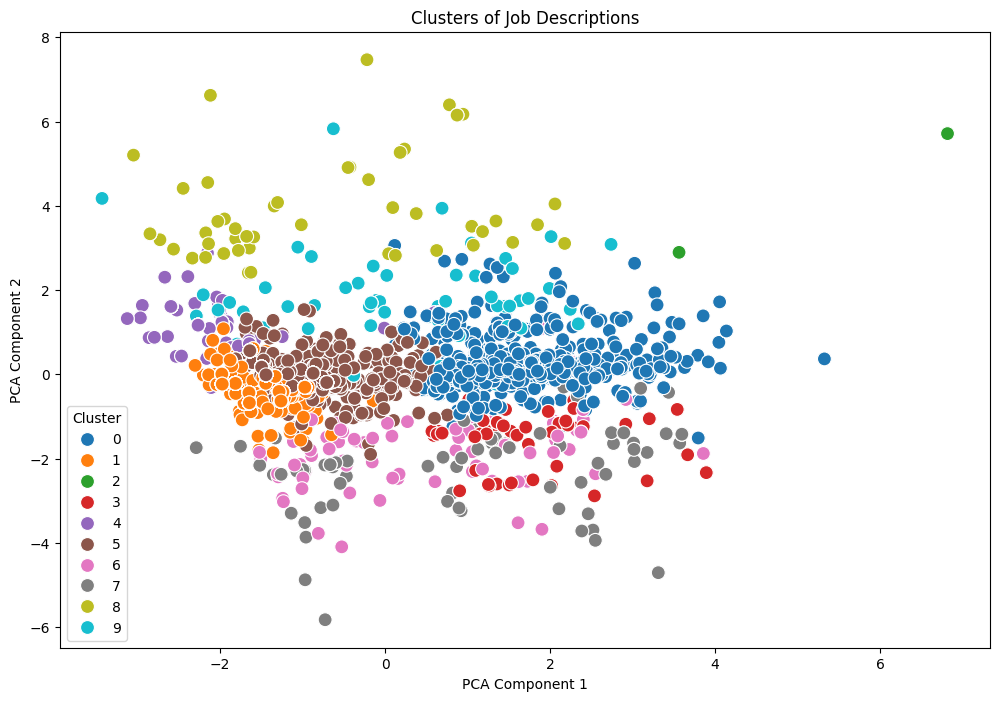

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Perform PCA to reduce to 2D
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# Create a DataFrame with the PCA results
pca_df = pd.DataFrame(data=pca_features, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = job_descriptions_df['Cluster']

# Plot the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=100)
plt.title('Clusters of Job Descriptions')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

In [37]:
skills_df = pd.read_excel('Hyphen_Removed_Skills_Data.xlsx')
# Get the list of skills from the third column
skills = skills_df.iloc[:, 2].dropna().tolist()
skills = pd.unique(skills).tolist()


job_titles = job_descriptions_df['Title']
job_descriptions = job_descriptions_df['Cleaned_Combined']

# Create an empty DataFrame for the JD-Skill matrix
jd_skill_matrix = pd.DataFrame(0, index=job_titles, columns=skills)

# Function to count the occurrences of skills in a text
def count_skills(text, skills_list):
    skill_counts = {skill: 0 for skill in skills_list}
    for skill in skills_list:
        skill_counts[skill] = text.lower().count(skill.lower())
    return skill_counts

# Populate the JD-Skill matrix
for i, job_description in enumerate(job_descriptions):
    skill_counts = count_skills(job_description, skills)
    for skill, count in skill_counts.items():
        jd_skill_matrix.loc[job_titles[i], skill] = count

print("JD-Skill Matrix created successfully!")

/var/folders/b7/5s7w4rhj08n_d300vg9kq81m0000gn/T/ipykernel_35924/1728330214.py:4: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  skills = pd.unique(skills).tolist()


JD-Skill Matrix created successfully!


In [38]:
# Assuming 'cluster_labels' is available from previous clustering
job_titles_df = pd.DataFrame({'Job_Title': job_titles, 'Cluster': kmeans.labels_})

# Merge the JD-Skill matrix with cluster labels
jd_skill_matrix['Cluster'] = job_titles_df['Cluster'].values

# Sum the rows cluster-wise
cluster_skill_matrix = jd_skill_matrix.groupby('Cluster').sum()

print("Cluster-Skill Matrix created successfully!")

Cluster-Skill Matrix created successfully!


In [39]:
cluster_skill_matrix

,Python,R,SQL,Java,Scala,C,C++,Javascript,Matlab,"Julia, Ruby",...,API design and development,Interpersonal skills,Time management,Continuous learning,Selfmotivation,Problemsolving,Critical thinking,Stakeholder management,Customer service,Writing skills
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1981,262009,926,693,611,164855,0,338,34,0,...,0,84,28,59,5,368,41,4,71,14
1,43,3786,0,2,0,2134,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,1242,8,4,4,878,0,0,0,0,...,0,0,0,0,0,0,4,0,0,0
3,122,19380,70,35,38,12770,0,12,4,0,...,0,10,12,0,0,33,0,0,0,0
4,6,601,2,4,2,389,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,273,23953,44,49,18,14876,0,14,0,0,...,0,6,0,6,0,16,4,0,0,0
6,106,17017,42,66,49,10313,0,18,4,0,...,0,7,0,1,0,11,0,0,0,0
7,100,21160,80,19,47,13858,0,5,0,0,...,0,9,5,7,0,27,2,2,4,0
8,55,7524,34,21,2,4639,0,11,0,0,...,0,0,0,0,0,20,0,0,0,0


In [40]:
# Initialize a DataFrame to store the top skills in each cluster
top_skills_per_cluster = pd.DataFrame(columns=['Skill', 'Cluster', 'Frequency'])

# Keep track of already assigned skills
assigned_skills = set()

# Transpose the DataFrame for easier processing
transposed_df = cluster_skill_matrix.T

# Iterate over each cluster to find the top 5 skills
for cluster in transposed_df.columns:
    # Sort skills by frequency in descending order
    sorted_skills = transposed_df[cluster].sort_values(ascending=False)
    
    # Select top skills that are not already assigned to other clusters
    top_skills = sorted_skills[~sorted_skills.index.isin(assigned_skills)].head(20)  # Adjust top_n as needed
    
    # Update assigned_skills with the selected top skills
    assigned_skills.update(top_skills.index)
    
    # Prepare DataFrame for top skills in this cluster
    top_skills_df = pd.DataFrame({
        'Skill': top_skills.index,
        'Cluster': cluster,
        'Frequency': top_skills.values
    })
    
    # Append to the final DataFrame
    top_skills_per_cluster = pd.concat([top_skills_per_cluster, top_skills_df], ignore_index=True)

# Drop any duplicated rows in case they exist due to previous issues
top_skills_per_cluster = top_skills_per_cluster.drop_duplicates()

# Display the top skills per cluster
print("Top Skills per Cluster:")
print(top_skills_per_cluster)

# Optionally, save the top skills per cluster to a CSV file
top_skills_per_cluster.to_csv('clust_skills_JD_feature.csv', index=False)

print("Top skills per cluster saved to 'top_skills_per_cluster.csv'")

Top Skills per Cluster:
                  Skill Cluster Frequency
0                     R       0    262009
1                     C       0    164855
2                  Stan       0      2720
3                Python       0      1981
4              Benefits       0      1385
..                  ...     ...       ...
195   Additional Skills       9         2
196          Enthusiasm       9         2
197  Business Analytics       9         2
198                QGIS       9         2
199        Thoroughness       9         2

[200 rows x 3 columns]
Top skills per cluster saved to 'top_skills_per_cluster.csv'


Co-occurrence Matrix

In [41]:
# Initialize co-occurrence matrix
num_skills = len(skills)
co_occurrence_matrix = np.zeros((num_skills, num_skills))

# Create a dictionary mapping skills to indices
skill_to_index = {skill: idx for idx, skill in enumerate(skills)}

# Populate the co-occurrence matrix
for _, row in jd_skill_matrix.iterrows():
    present_skills = row[row > 0].index.tolist()
    for i in range(len(present_skills)):
        skill1 = present_skills[i]
        if skill1 == 'Cluster':  # Skip the 'Cluster' column
            continue
        for j in range(i + 1, len(present_skills)):
            skill2 = present_skills[j]
            if skill2 == 'Cluster':  # Skip the 'Cluster' column
                continue
            idx1 = skill_to_index[skill1]
            idx2 = skill_to_index[skill2]
            co_occurrence_matrix[idx1, idx2] = 1
            co_occurrence_matrix[idx2, idx1] = 1

# Convert to DataFrame for better readability (optional)
co_occurrence_df = pd.DataFrame(co_occurrence_matrix, index=skills, columns=skills)

In [42]:
file_path = 'co_occurrence_JD_feature_skills_cluster.csv'
co_occurrence_df.to_csv(file_path, index=True)

In [43]:
co_occurrence_df

,Python,R,SQL,Java,Scala,C,C++,Javascript,Matlab,"Julia, Ruby",...,API design and development,Interpersonal skills,Time management,Continuous learning,Selfmotivation,Problemsolving,Critical thinking,Stakeholder management,Customer service,Writing skills
Python,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
R,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
SQL,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Java,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
Scala,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Problemsolving,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0
Critical thinking,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
Stakeholder management,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Customer service,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0


In [44]:
import openai
from openai import OpenAI
# OPENAI_API_KEY = 'REDACTED'
client = OpenAI(api_key='REDACTED',)

In [46]:
def generate_curriculum(file):
    data = pd.read_csv(file)
    skills = data.to_string(index=False)
    response = client.chat.completions.create(
    model="gpt-4-0125-preview",
    messages=[
            {"role": "system", "content": "You are a helpful assistant specialized in analysing the skills which have been clustered based on the embeddings of the job descriptions."},
            {"role": "user", "content": f"""I have a CSV file containing skills with their frequency across different clusters from job descriptions. I need to cluster these skills based on their relatedness and then design a curriculum with around 10 courses, allocating the clustered skills to each course. CSV_content:{skills}
            Give the output as curriculum designed with about 10 courses, the similar skills grouped together. Remember, the curriculum design is for a Masters in Management in Artificial Intelligence Program (MMAI), intersection of MBA and AI, so feel free to drop in other relevant skills in the courses which might have been missed in the {skills}
            """}], 
    max_tokens = 4096,
    temperature = 0,
    top_p = 1
  )
    response_content = response.choices[0].message.content
   # Parse response content as JSON
    print(response_content)
    # Save the collected skills and their embeddings to a JSON file
    with open('curriculum_JD_feature_skills.json', 'w') as json_file:
      json.dump(response_content, json_file, indent=4)

In [47]:
generate_curriculum('clust_skills_JD_feature.csv')

Designing a curriculum for a Masters in Management in Artificial Intelligence (MMAI) program involves integrating core management principles with cutting-edge artificial intelligence (AI) technologies. Based on the provided CSV content, we can cluster related skills and allocate them to courses that reflect the interdisciplinary nature of this program. Here's a proposed curriculum with 10 courses, each focusing on a specific area of intersection between management and AI:

### 1. Introduction to Management and AI
- **Skills Covered:** Management, Communication, Collaboration, Leadership, Teamwork, Interpersonal Skills, Interpersonal skills, Organizational Skills, DecisionMaking, Decisionmaking, Positive Attitude, Enthusiasm, Motivation, Accountability, Creativity.
- **Description:** This foundational course introduces the principles of management within the context of AI, emphasizing effective communication, leadership, and teamwork in tech-driven environments.

### 2. Programming for 